In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv")
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')

Grid-search training rows: 20976
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best XGBoost params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV score neg MAE: -1659.3278

Monthly refit 1/6 — 2025-07-01
  Train rows: 20976 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=1304.02 | RMSE=1553.71 | MAPE=9.21%

Monthly refit 2/6 — 2025-08-01
  Train rows: 21720 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=1035.89 | RMSE=1257.71 | MAPE=8.40%

Monthly refit 3/6 — 2025-09-01
  Train rows: 22464 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=1897.96 | RMSE=2194.03 | MAPE=17.01%

Monthly refit 4/6 — 2025-10-01
  Train rows: 23184 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=692.75 | RMSE=901.92 | MAPE=8.87%

Monthly refit 5/6 — 2025-11-01
  Train rows: 23928 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=423.11 | RMSE=563.92 | MAPE=5.13%

Mo

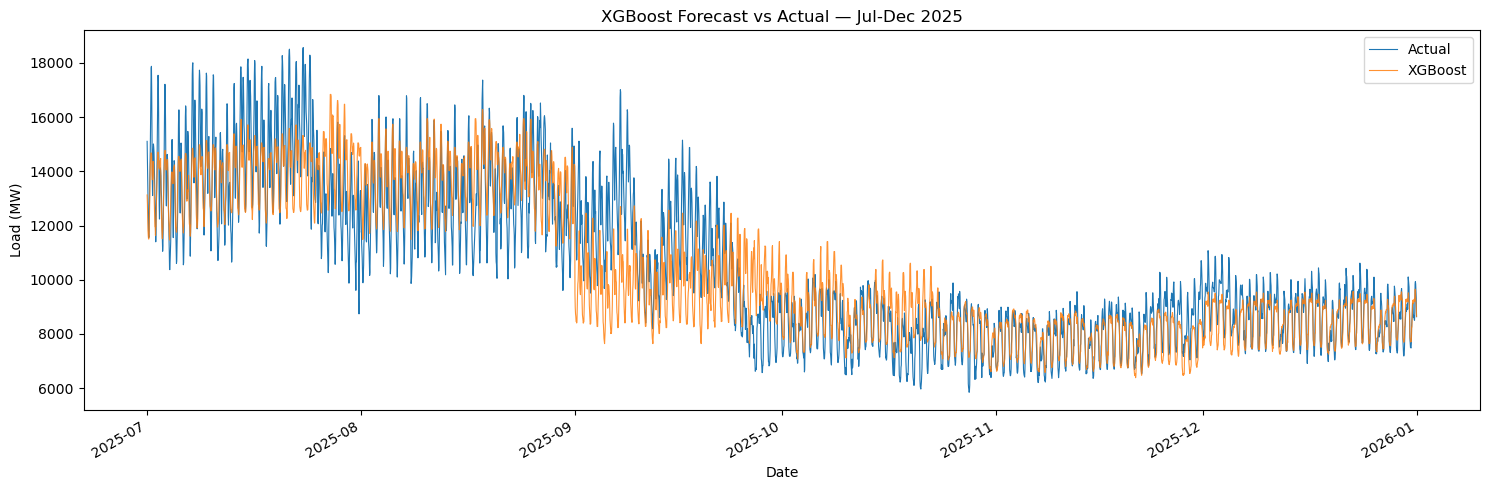

🏃 View run XGBoost_walkforward_gridsearch_calendar_only at: http://127.0.0.1:5000/#/experiments/531580567308328190/runs/f1107bc6fd7341f9a4c1731af98076de
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/531580567308328190


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")

# ============================================================
# 1) SETTINGS
# ============================================================
target_col = "load"

feature_cols = [
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "month_sin", "month_cos",
    "hour", "day_of_week", "month", "year",'post_breakpoint','lag_744'
]

month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# ============================================================
# 2) GRID SEARCH ONCE ON PRE-JULY 2025 TRAINING DATA
# ============================================================
grid_train_end = pd.Timestamp("2025-06-30 23:00:00")

grid_train_df = df.loc[:grid_train_end].dropna(
    subset=feature_cols + [target_col]
).copy()

X_grid = grid_train_df[feature_cols]
y_grid = grid_train_df[target_col]

print(f"Grid-search training rows: {len(X_grid)}", flush=True)

base_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_grid, y_grid)

best_params = grid.best_params_
best_cv_score = grid.best_score_

print("\nBest XGBoost params:")
print(best_params)
print(f"Best CV score neg MAE: {best_cv_score:.4f}")

# ============================================================
# 3) MONTHLY WALK-FORWARD WITH FIXED BEST PARAMS
# ============================================================
preds_xgb = []
actuals_xgb = []
monthly_metrics = []

for i, month_origin in enumerate(month_origins):
    print(f"\n{'='*60}", flush=True)
    print(f"Monthly refit {i+1}/6 — {month_origin.date()}", flush=True)

    next_month_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01 00:00:00")
    )

    train_df = df.loc[: month_origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    test_df = df.loc[
        (df.index >= month_origin) & (df.index < next_month_origin)
    ].dropna(subset=feature_cols + [target_col]).copy()

    if len(test_df) == 0:
        print("  Skipped — empty test block", flush=True)
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    model = XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred_month = pd.Series(model.predict(X_test), index=y_test.index)

    preds_xgb.append(pred_month)
    actuals_xgb.append(y_test)

    mae_m = np.mean(np.abs(y_test - pred_month))
    rmse_m = np.sqrt(np.mean((y_test - pred_month) ** 2))
    mape_m = np.mean(np.abs((y_test - pred_month) / y_test)) * 100

    monthly_metrics.append({
        "origin_month": month_origin.strftime("%Y-%m"),
        "n_hours": len(y_test),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

    print(f"  Train rows: {len(X_train)} | Test rows: {len(X_test)}", flush=True)
    print(f"  Done — {len(y_test)} hours forecasted", flush=True)
    print(f"  Monthly MAE={mae_m:.2f} | RMSE={rmse_m:.2f} | MAPE={mape_m:.2f}%", flush=True)

# ============================================================
# 4) OVERALL METRICS
# ============================================================
pred_xgb = pd.concat(preds_xgb).sort_index()
actual_xgb = pd.concat(actuals_xgb).sort_index()

mae = np.mean(np.abs(actual_xgb - pred_xgb))
rmse = np.sqrt(np.mean((actual_xgb - pred_xgb) ** 2))
mape = np.mean(np.abs((actual_xgb - pred_xgb) / actual_xgb)) * 100

print(f"\nXGBoost Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 5) MONTHLY METRICS + CSV
# ============================================================
monthly_metrics_df = pd.DataFrame(monthly_metrics)

print("\nMonthly metrics by origin:")
print(monthly_metrics_df)

monthly_metrics_df.to_csv("xgb_monthly_metrics.csv", index=False)

pred_vs_actual_df = pd.DataFrame({
    "actual": actual_xgb,
    "predicted": pred_xgb
})
pred_vs_actual_df.to_csv("xgb_predictions.csv")

# ============================================================
# 6) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(actual_xgb.index, actual_xgb.values, label="Actual", linewidth=0.8)
ax.plot(pred_xgb.index, pred_xgb.values, label="XGBoost", linewidth=0.8, alpha=0.85)

ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("XGBoost Forecast vs Actual — Jul-Dec 2025")
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================
# 7) MLFLOW LOGGING
# ============================================================
with mlflow.start_run(run_name="XGBoost_walkforward_gridsearch_calendar_only"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("features", "calendar_only")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")
    mlflow.log_param("search_type", "GridSearchCV_once")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("cv_splits", 3)

    for k, v in best_params.items():
        mlflow.log_param(f"best_{k}", v)

    mlflow.log_metric("grid_best_cv_score_neg_mae", float(best_cv_score))
    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    mlflow.log_artifact("xgb_monthly_metrics.csv")
    mlflow.log_artifact("xgb_predictions.csv")

    fig.savefig("xgb_forecast.png")
    mlflow.log_artifact("xgb_forecast.png")

In [5]:
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month'
]

target_col = 'load'

month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_hybrid = []
actuals = []

for i, origin in enumerate(month_origins):
    print(f"\nOrigin {i+1}/6 — {origin.date()}")

    next_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01")
    )

    # -------------------------
    # TRAIN DATA
    # -------------------------
    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna().copy()

    y_train = train_df[target_col]

    # -------------------------
    # SARIMA FIT
    # -------------------------
    sarima = SARIMAX(
        y_train,
        order=(2,0,0),
        seasonal_order=(0,1,1,24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit = sarima.fit(disp=False)

    # in-sample fitted values
    fitted = sarima_fit.fittedvalues

    # residuals
    residuals = y_train - fitted

    # -------------------------
    # TRAIN XGBOOST ON RESIDUALS
    # -------------------------
    X_train = train_df[feature_cols]

    xgb = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(X_train, residuals, eval_set=[(X_train.tail(168), residuals.tail(168))], verbose=False)

    # -------------------------
    # FORECAST MONTH
    # -------------------------
    test_df = df.loc[
        (df.index >= origin) & (df.index < next_origin)
    ].copy()

    y_test = test_df[target_col]

    # SARIMA forecast
    sarima_forecast = sarima_fit.forecast(steps=len(test_df))

    # XGB residual forecast
    X_test = test_df[feature_cols]
    residual_pred = xgb.predict(X_test)

    # FINAL HYBRID
    final_pred = sarima_forecast.values + residual_pred

    pred_series = pd.Series(final_pred, index=y_test.index)

    preds_hybrid.append(pred_series)
    actuals.append(y_test)

    print(f"Done — {len(y_test)} hours forecasted")

# =========================
# METRICS
# =========================
pred = pd.concat(preds_hybrid)
actual = pd.concat(actuals)

mae  = np.mean(np.abs(actual - pred))
rmse = np.sqrt(np.mean((actual - pred) ** 2))
mape = np.mean(np.abs((actual - pred) / actual)) * 100

print("\nHybrid SARIMA-XGBoost Results")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAPE = {mape:.2f}%")


Origin 1/6 — 2025-07-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done — 744 hours forecasted

Origin 2/6 — 2025-08-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done — 744 hours forecasted

Origin 3/6 — 2025-09-01


...

Done — 744 hours forecasted

Origin 5/6 — 2025-11-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done — 720 hours forecasted

Origin 6/6 — 2025-12-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done — 744 hours forecasted

Hybrid SARIMA-XGBoost Results
MAE  = 921.33
RMSE = 1394.04
MAPE = 9.11%


In [3]:
df['post_breakpoint']=(df.index >= '2024-07-01').astype(int)
df['lag_365']=df['load'].shift(365*24)
df['lag_744']=df['load'].shift(744)

In [3]:
df.head()

,load,hour,day_of_week,month,year,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,...,rolling_mean_168,rolling_std_168,lag_1,lag_2,lag_24,lag_48,lag_168,post_breakpoint,lag_365,lag_744
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-08 00:00:00,5709.50,0,6,1,2023,0.000000,1.000000,-0.781831,0.62349,0.5,...,6297.699405,684.279363,6252.50,6828.50,5706.25,5930.5,5317.916667,0,NaN,NaN
2023-01-08 01:00:00,5501.25,1,6,1,2023,0.258819,0.965926,-0.781831,0.62349,0.5,...,6300.030258,681.583568,5709.50,6252.50,5507.50,5561.5,5271.333333,0,NaN,NaN
2023-01-08 02:00:00,5439.25,2,6,1,2023,0.500000,0.866025,-0.781831,0.62349,0.5,...,6301.398810,679.733994,5501.25,5709.50,5390.75,5583.5,5142.833333,0,NaN,NaN
2023-01-08 03:00:00,5409.75,3,6,1,2023,0.707107,0.707107,-0.781831,0.62349,0.5,...,6303.163194,677.088254,5439.25,5501.25,5361.00,5444.5,5110.250000,0,NaN,NaN
2023-01-08 04:00:00,5376.75,4,6,1,2023,0.866025,0.500000,-0.781831,0.62349,0.5,...,6304.945933,674.317182,5409.75,5439.25,5358.25,5414.5,5126.833333,0,NaN,NaN


Grid-search training rows: 20976


Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best params from one-time GridSearch:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV score (neg MAE): -1659.3278

Monthly refit 1/6 — 2025-07-01
  Train rows: 20976 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 2/6 — 2025-08-01
  Train rows: 21720 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 3/6 — 2025-09-01
  Train rows: 22464 | Test rows: 720
  Done — 720 hours forecasted

Monthly refit 4/6 — 2025-10-01
  Train rows: 23184 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 5/6 — 2025-11-01
  Train rows: 23928 | Test rows: 720
  Done — 720 hours forecasted

Monthly refit 6/6 — 2025-12-01
  Train rows: 24648 | Test rows: 744
  Done — 744 hours forecasted

XGBoost Walk-Forward Results
MAE  = 957.10 MW
RMSE = 1300.52 MW
MAPE = 8.82 %


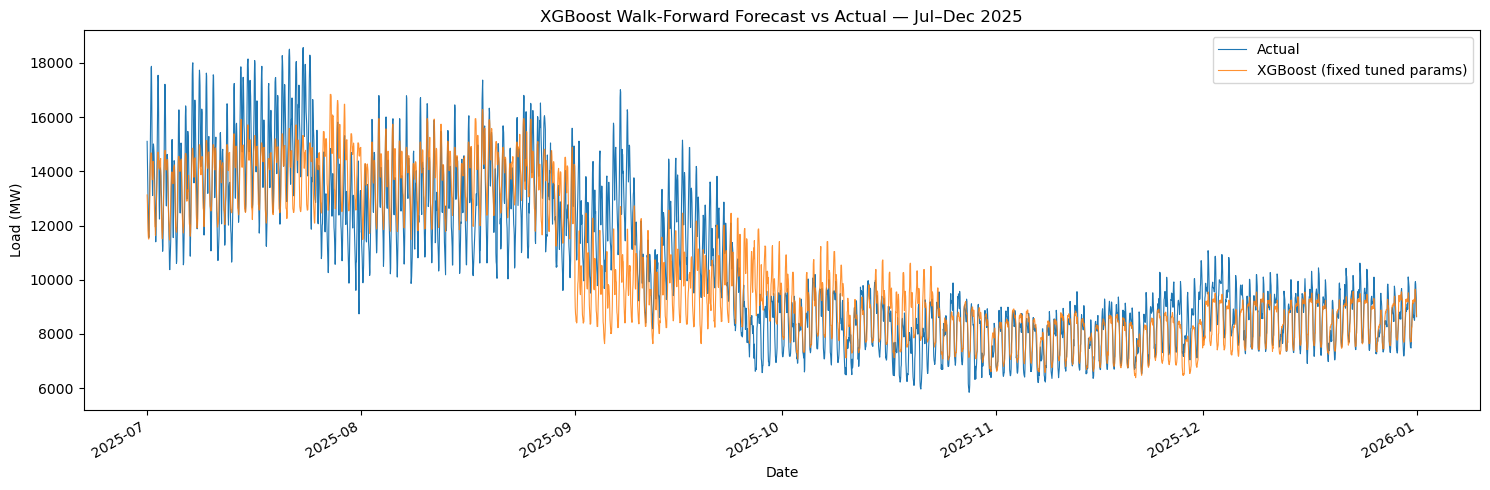

In [7]:

# ── leakage-safe features for monthly block forecasting ───────
feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year','post_breakpoint','lag_744'
]
target_col = 'load'

# ============================================================
# 1) GRID SEARCH ONCE ON PRE-JULY-2025 TRAINING DATA
# ============================================================
grid_train_end = pd.Timestamp("2025-06-30 23:00:00")

grid_train_df = df.loc[:grid_train_end].dropna(
    subset=feature_cols + [target_col]
).copy()

X_grid = grid_train_df[feature_cols]
y_grid = grid_train_df[target_col]

print(f"Grid-search training rows: {len(X_grid)}", flush=True)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

base_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_grid, y_grid)

best_params = grid.best_params_
best_cv_score = grid.best_score_

print("\nBest params from one-time GridSearch:")
print(best_params)
print(f"Best CV score (neg MAE): {best_cv_score:.4f}")

# ============================================================
# 2) MONTHLY WALK-FORWARD WITH FIXED BEST PARAMS
# ============================================================
month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_xgb = []
actuals_xgb = []

for i, month_origin in enumerate(month_origins):
    print(f"\n{'='*60}", flush=True)
    print(f"Monthly refit {i+1}/6 — {month_origin.date()}", flush=True)

    next_month_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01 00:00:00")
    )

    train_df = df.loc[: month_origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    test_df = df.loc[
        (df.index >= month_origin) & (df.index < next_month_origin)
    ].dropna(subset=feature_cols + [target_col]).copy()

    if len(test_df) == 0:
        print("  Skipped — empty test block", flush=True)
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **best_params
    )

    model.fit(X_train, y_train)
    pred_month = pd.Series(model.predict(X_test), index=y_test.index)

    preds_xgb.append(pred_month)
    actuals_xgb.append(y_test)

    print(f"  Train rows: {len(X_train)} | Test rows: {len(X_test)}", flush=True)
    print(f"  Done — {len(y_test)} hours forecasted", flush=True)

pred_xgb   = pd.concat(preds_xgb).sort_index()
actual_xgb = pd.concat(actuals_xgb).sort_index()

mae  = np.mean(np.abs(actual_xgb - pred_xgb))
rmse = np.sqrt(np.mean((actual_xgb - pred_xgb) ** 2))
mape = np.mean(np.abs((actual_xgb - pred_xgb) / actual_xgb)) * 100

print(f"\nXGBoost Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 3) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_xgb.index, actual_xgb.values, label="Actual", linewidth=0.8)
ax.plot(pred_xgb.index, pred_xgb.values, label="XGBoost (fixed tuned params)", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("XGBoost Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# 4) MLFLOW LOGGING
# ============================================================
with mlflow.start_run(run_name="XGBoost_walkforward_fixed_tuned_params"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("features", "calendar_only")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")
    mlflow.log_param("search_type", "GridSearchCV_once")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("cv_splits", 3)

    for k, v in best_params.items():
        mlflow.log_param(f"best_{k}", v)

    mlflow.log_metric("grid_best_cv_score_neg_mae", float(best_cv_score))
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)

    fig.savefig("xgb_fixed_tuned_forecast.png")
    mlflow.log_artifact("xgb_fixed_tuned_forecast.png")


Monthly refit 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744
  Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  Best CV score (neg MAE): -483.6959
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Done — 744 hours forecasted

Monthly refit 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744
  Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  Best CV score (neg MAE): -484.3672
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  Done — 744 hours forecasted

Monthly refit 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720
  Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  Best CV score (neg MAE): -543.3247
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
 

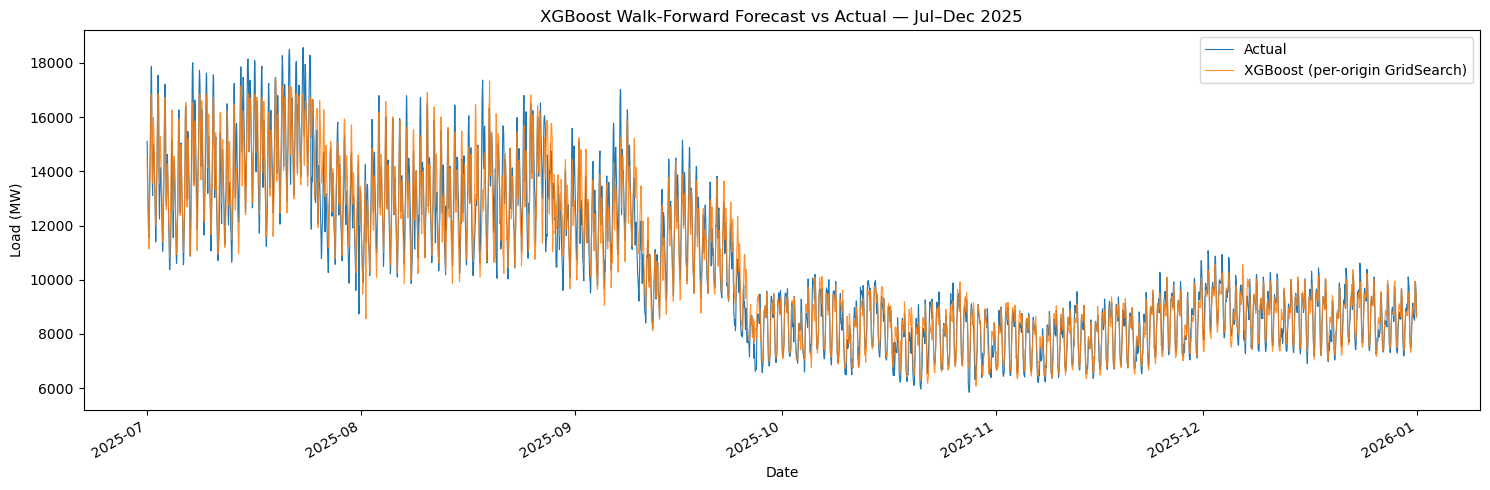


Best params by origin:
            colsample_bytree  learning_rate  max_depth  n_estimators  \
2025-07-01               1.0           0.05          3           200   
2025-08-01               1.0           0.05          3           200   
2025-09-01               1.0           0.05          3           200   
2025-10-01               1.0           0.05          3           200   
2025-11-01               1.0           0.05          3           200   
2025-12-01               1.0           0.05          3           200   

            subsample  best_cv_score_neg_mae  
2025-07-01        0.8            -483.695942  
2025-08-01        1.0            -484.367167  
2025-09-01        1.0            -543.324654  
2025-10-01        1.0            -499.875652  
2025-11-01        0.8            -506.005482  
2025-12-01        0.8            -460.822389  
🏃 View run XGBoost_walkforward_gridsearch_each_origin at: http://127.0.0.1:5000/#/experiments/4/runs/e68f2e30ca77408a92fd1503d4b2f75f
🧪 View e

In [ ]:


from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Load_Forecasting")

# ── leakage-safe features for monthly block forecasting ───────
feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]
target_col = 'load'

month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_xgb = []
actuals_xgb = []
best_params_by_origin = []
best_cv_scores = []

# ── keep the grid modest first, so you can judge runtime ──────
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

for i, month_origin in enumerate(month_origins):
    print(f"\n{'='*60}", flush=True)
    print(f"Monthly refit {i+1}/6 — {month_origin.date()}", flush=True)

    next_month_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01 00:00:00")
    )

    train_df = df.loc[: month_origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    test_df = df.loc[
        (df.index >= month_origin) & (df.index < next_month_origin)
    ].dropna(subset=feature_cols + [target_col]).copy()

    if len(test_df) == 0:
        print("  Skipped — empty test block", flush=True)
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    print(f"  Train rows: {len(X_train)} | Test rows: {len(X_test)}", flush=True)

    base_xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    tscv = TimeSeriesSplit(n_splits=3)

    grid = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1
    )

    print("  Starting GridSearchCV...", flush=True)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    pred_month = pd.Series(best_model.predict(X_test), index=y_test.index)

    preds_xgb.append(pred_month)
    actuals_xgb.append(y_test)
    best_params_by_origin.append(grid.best_params_)
    best_cv_scores.append(grid.best_score_)

    print(f"  Best CV score (neg MAE): {grid.best_score_:.4f}", flush=True)
    print(f"  Best params: {grid.best_params_}", flush=True)
    print(f"  Done — {len(y_test)} hours forecasted", flush=True)

pred_xgb   = pd.concat(preds_xgb).sort_index()
actual_xgb = pd.concat(actuals_xgb).sort_index()

mae  = np.mean(np.abs(actual_xgb - pred_xgb))
rmse = np.sqrt(np.mean((actual_xgb - pred_xgb) ** 2))
mape = np.mean(np.abs((actual_xgb - pred_xgb) / actual_xgb)) * 100

print(f"\nXGBoost Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_xgb.index, actual_xgb.values, label="Actual", linewidth=0.8)
ax.plot(pred_xgb.index, pred_xgb.values, label="XGBoost (per-origin GridSearch)", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("XGBoost Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

params_df = pd.DataFrame(best_params_by_origin, index=month_origins[:len(best_params_by_origin)])
params_df["best_cv_score_neg_mae"] = best_cv_scores

print("\nBest params by origin:")
print(params_df)

with mlflow.start_run(run_name="XGBoost_walkforward_gridsearch_each_origin"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("features", "calendar_only")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")
    mlflow.log_param("search_type", "GridSearchCV_each_origin")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("cv_splits", 3)
    mlflow.log_param("param_grid", str(param_grid))

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)

    fig.savefig("xgb_gridsearch_each_origin_forecast.png")
    mlflow.log_artifact("xgb_gridsearch_each_origin_forecast.png")

    params_df.to_csv("xgb_best_params_by_origin.csv")
    mlflow.log_artifact("xgb_best_params_by_origin.csv")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from xgboost import XGBRegressor

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Load_Forecasting")


<Experiment: artifact_location='mlflow-artifacts:/4', creation_time=1775569554986, experiment_id='4', last_update_time=1775569554986, lifecycle_stage='active', name='Electricity_Load_Forecasting', tags={}, workspace='default'>


Monthly refit 1/6 — 2025-07-01
  Train rows: 20977 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 2/6 — 2025-08-01
  Train rows: 21721 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 3/6 — 2025-09-01
  Train rows: 22465 | Test rows: 720
  Done — 720 hours forecasted

Monthly refit 4/6 — 2025-10-01
  Train rows: 23185 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 5/6 — 2025-11-01
  Train rows: 23929 | Test rows: 720
  Done — 720 hours forecasted

Monthly refit 6/6 — 2025-12-01
  Train rows: 24649 | Test rows: 744
  Done — 744 hours forecasted

XGBoost Walk-Forward Results
MAE  = 1016.51 MW
RMSE = 1424.80 MW
MAPE = 9.92 %


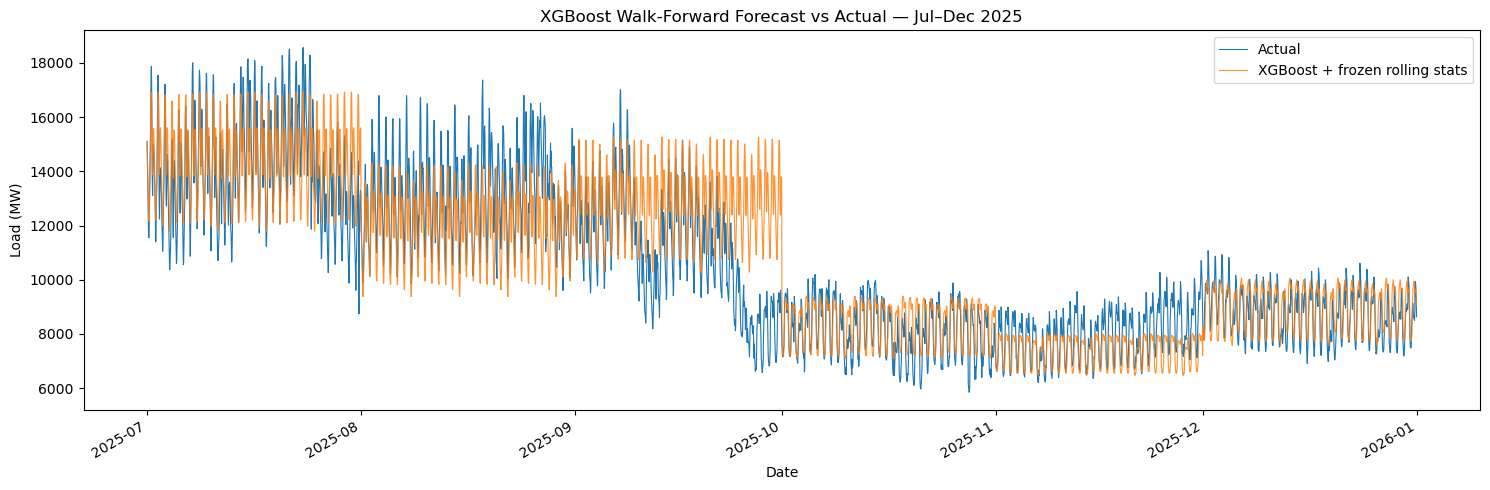

🏃 View run XGBoost_walkforward_frozen_rolling_stats at: http://127.0.0.1:5000/#/experiments/4/runs/6f1b376a7eca46bbb0022a3fcda7d380
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [12]:

# ============================================================
# 1) CREATE SAFE ROLLING FEATURES ON THE HISTORICAL SERIES
# ============================================================
df = df.copy()

df['mean_last_24h']  = df['load'].rolling(24).mean()
df['std_last_24h']   = df['load'].rolling(24).std()

df['mean_last_168h'] = df['load'].rolling(168).mean()
df['std_last_168h']  = df['load'].rolling(168).std()

df['mean_last_744h'] = df['load'].rolling(744).mean()
df['std_last_744h']  = df['load'].rolling(744).std()

# ============================================================
# 2) FEATURES
# ============================================================
base_feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]

roll_feature_cols = [
    'mean_last_24h', 'std_last_24h',
    'mean_last_168h', 'std_last_168h',
    'mean_last_744h', 'std_last_744h'
]

feature_cols = base_feature_cols + roll_feature_cols
target_col = 'load'

# ============================================================
# 3) FIXED XGBOOST PARAMS
#    replace these if you already have tuned params
# ============================================================
best_params = {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.025,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

# ============================================================
# 4) MONTHLY WALK-FORWARD
# ============================================================
month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_xgb = []
actuals_xgb = []

for i, month_origin in enumerate(month_origins):
    print(f"\n{'='*60}", flush=True)
    print(f"Monthly refit {i+1}/6 — {month_origin.date()}", flush=True)

    next_month_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01 00:00:00")
    )

    # -------------------------
    # training data before origin
    # -------------------------
    train_df = df.loc[: month_origin - pd.Timedelta(hours=1)].copy()

    # keep naturally computed historical rolling features
    train_df = train_df.dropna(subset=feature_cols + [target_col])

    # -------------------------
    # raw test block
    # -------------------------
    test_df = df.loc[
        (df.index >= month_origin) & (df.index < next_month_origin)
    ].copy()

    if len(test_df) == 0:
        print("  Skipped — empty test block", flush=True)
        continue

    # -------------------------
    # freeze rolling summaries at origin
    # -------------------------
    last_hist = month_origin - pd.Timedelta(hours=1)

    m24  = df.loc[last_hist, 'mean_last_24h']
    s24  = df.loc[last_hist, 'std_last_24h']
    m168 = df.loc[last_hist, 'mean_last_168h']
    s168 = df.loc[last_hist, 'std_last_168h']
    m744 = df.loc[last_hist, 'mean_last_744h']
    s744 = df.loc[last_hist, 'std_last_744h']

    test_df['mean_last_24h']  = m24
    test_df['std_last_24h']   = s24
    test_df['mean_last_168h'] = m168
    test_df['std_last_168h']  = s168
    test_df['mean_last_744h'] = m744
    test_df['std_last_744h']  = s744

    test_df = test_df.dropna(subset=base_feature_cols + [target_col])

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    print(f"  Train rows: {len(X_train)} | Test rows: {len(X_test)}", flush=True)

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **best_params
    )

    model.fit(X_train, y_train)

    pred_month = pd.Series(model.predict(X_test), index=y_test.index)

    preds_xgb.append(pred_month)
    actuals_xgb.append(y_test)

    print(f"  Done — {len(y_test)} hours forecasted", flush=True)

# ============================================================
# 5) METRICS
# ============================================================
pred_xgb   = pd.concat(preds_xgb).sort_index()
actual_xgb = pd.concat(actuals_xgb).sort_index()

mae  = np.mean(np.abs(actual_xgb - pred_xgb))
rmse = np.sqrt(np.mean((actual_xgb - pred_xgb) ** 2))
mape = np.mean(np.abs((actual_xgb - pred_xgb) / actual_xgb)) * 100

print(f"\nXGBoost Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 6) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_xgb.index, actual_xgb.values, label="Actual", linewidth=0.8)
ax.plot(pred_xgb.index, pred_xgb.values, label="XGBoost + frozen rolling stats", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("XGBoost Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================
# 7) MLFLOW
# ============================================================
with mlflow.start_run(run_name="XGBoost_walkforward_frozen_rolling_stats"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("features", "calendar_plus_frozen_rolling_stats")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")

    for k, v in best_params.items():
        mlflow.log_param(f"best_{k}", v)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)

    fig.savefig("xgb_frozen_rolling_stats_forecast.png")
    mlflow.log_artifact("xgb_frozen_rolling_stats_forecast.png")


Weekly refit 1/27 — 2025-07-01 00:00:00
  Train rows: 21720 | Test rows: 168
  Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  Best CV score (neg MAE): -1233.6936
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Done — 168 hours forecasted

Weekly refit 2/27 — 2025-07-08 00:00:00
  Train rows: 21888 | Test rows: 168
  Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  Best CV score (neg MAE): -1237.8510
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Done — 168 hours forecasted

Weekly refit 3/27 — 2025-07-15 00:00:00
  Train rows: 22056 | Test rows: 168
  Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  Best CV score (neg MAE): -1248.4171
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimat

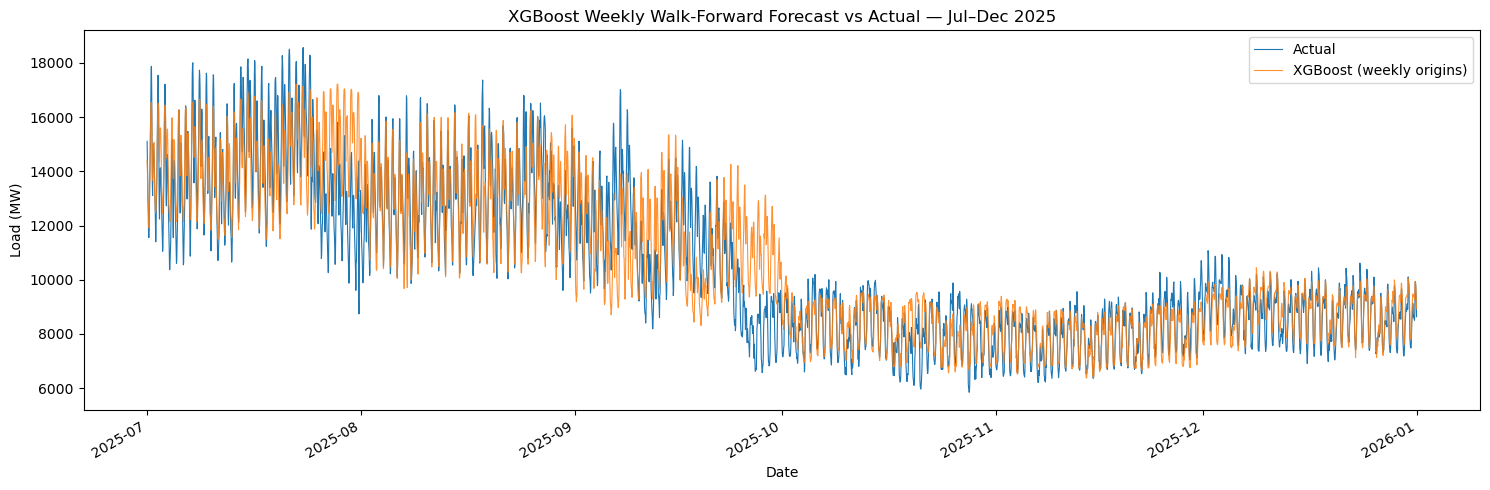


Best params by origin:
            colsample_bytree  learning_rate  max_depth  n_estimators  \
2025-07-01               0.8           0.05          3           200   
2025-07-08               0.8           0.05          3           200   
2025-07-15               0.8           0.05          3           200   
2025-07-22               0.8           0.05          3           200   
2025-07-29               0.8           0.05          3           200   
2025-08-05               0.8           0.05          3           200   
2025-08-12               0.8           0.05          3           200   
2025-08-19               0.8           0.05          3           200   
2025-08-26               0.8           0.05          3           200   
2025-09-02               0.8           0.05          3           200   
2025-09-09               0.8           0.05          3           200   
2025-09-16               0.8           0.05          3           200   
2025-09-23               0.8           0

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


# ============================================================
# 1) FEATURES
#    Weekly block forecast (168h), so lag_168 is safe for the
#    whole block. Shorter lags are still unsafe for later hours.
# ============================================================
feature_cols = [
    'lag_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]
target_col = 'load'

# ============================================================
# 2) WEEKLY ORIGINS OVER THE 6-MONTH TEST PERIOD
# ============================================================
week_origins = pd.date_range("2025-07-01", "2025-12-31", freq="7D")

preds_xgb = []
actuals_xgb = []
best_params_by_origin = []
best_cv_scores = []

# modest grid first, so you can judge runtime
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

for i, origin in enumerate(week_origins):
    print(f"\n{'='*60}", flush=True)
    print(f"Weekly refit {i+1}/{len(week_origins)} — {origin}", flush=True)

    horizon_end = origin + pd.Timedelta(hours=167)

    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    test_df = df.loc[origin : horizon_end].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    if len(test_df) == 0:
        print("  Skipped — empty test block", flush=True)
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    print(f"  Train rows: {len(X_train)} | Test rows: {len(X_test)}", flush=True)

    base_xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    tscv = TimeSeriesSplit(n_splits=3)

    grid = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1
    )

    print("  Starting GridSearchCV...", flush=True)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    pred_week = pd.Series(best_model.predict(X_test), index=y_test.index)

    preds_xgb.append(pred_week)
    actuals_xgb.append(y_test)
    best_params_by_origin.append(grid.best_params_)
    best_cv_scores.append(grid.best_score_)

    print(f"  Best CV score (neg MAE): {grid.best_score_:.4f}", flush=True)
    print(f"  Best params: {grid.best_params_}", flush=True)
    print(f"  Done — {len(y_test)} hours forecasted", flush=True)

pred_xgb   = pd.concat(preds_xgb).sort_index()
actual_xgb = pd.concat(actuals_xgb).sort_index()

mae  = np.mean(np.abs(actual_xgb - pred_xgb))
rmse = np.sqrt(np.mean((actual_xgb - pred_xgb) ** 2))
mape = np.mean(np.abs((actual_xgb - pred_xgb) / actual_xgb)) * 100

print(f"\nXGBoost Weekly Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_xgb.index, actual_xgb.values, label="Actual", linewidth=0.8)
ax.plot(pred_xgb.index, pred_xgb.values, label="XGBoost (weekly origins)", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("XGBoost Weekly Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

params_df = pd.DataFrame(
    best_params_by_origin,
    index=week_origins[:len(best_params_by_origin)]
)
params_df["best_cv_score_neg_mae"] = best_cv_scores

print("\nBest params by origin:")
print(params_df)

